In [1]:
import pickle
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.functional as F
from tqdm import tqdm

In [2]:
with open("data", "rb") as f:
    data = pickle.load(f)

In [3]:
bad = data.get("bad").copy()
good = data.get("good").copy()

In [4]:
index_chunks_b = np.split(np.arange(len(bad)),
                        # identified zeros
                        np.where(bad.index == 0)[0][1:])
index_chunks_g = np.split(np.arange(len(good)),
                        # identified zeros
                        np.where(good.index == 0)[0][1:])

In [5]:
M = []
for chunk in index_chunks_b:
    df = bad.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
    observation = {"X" : df.to_numpy(), "Y" : np.zeros((1,1),dtype=np.int64)}
    observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
    observation["Y"] = torch.from_numpy(observation["Y"])                                    
    M.append(observation)
for chunk in index_chunks_g:
    df = good.iloc[chunk][['MS2.mz', 'MS2.intensity']].copy()
    observation = {"X" : df.to_numpy(), "Y" : np.ones((1,1),dtype=np.int64)}
    observation["X"] = torch.from_numpy(observation["X"]).unsqueeze(0)
    observation["Y"] = torch.from_numpy(observation["Y"])
    M.append(observation)

In [6]:
np.random.seed(1337)
np.random.shuffle(M)
test = M[:100]
val  = M[100:200]
train = M[200:]

In [7]:
def get_n_params(model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn
    return pp

class Attention(nn.Module):
    def __init__(self, emb, heads):
        super().__init__()

        assert emb % heads == 0, f'Embedding dimension ({emb}) should be divisible by nr. of heads ({heads})'

        self.emb = emb
        self.heads = heads

        self.W_k    = nn.Linear(emb, emb, bias=False)
        self.W_q = nn.Linear(emb, emb, bias=False)
        self.W_v  = nn.Linear(emb, emb, bias=False)
        self.W_u = nn.Linear(emb, emb)

    def forward(self, X):

        b, t, e = X.size()
        h = self.heads
        assert e == self.emb, f'Input embedding dim ({e}) should match layer embedding dim ({self.emb})'
        # chunksize of e, i.e. head dim
        s = e // h
        # query, key, value model
        K = self.W_k(X)
        Q = self.W_q(X)
        V = self.W_v(X)
        # split
        K = K.view(b, t, h, s)
        Q = Q.view(b, t, h, s)
        V = V.view(b, t, h, s)
        # prepare for dot product and scale (pbloem)
        K = K.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))
        Q = Q.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))
        V = V.transpose(1,2).contiguous().view(b * h, t, s) / (e ** (1/4))

        W = Q@K.transpose(1,2)
        W = torch.softmax(W, dim=2)

        assert W.size() == (b*h, t, t)

        Y = W@V
        Y = Y.view(b, h, t, s)

        # re-arange and unify heads 
        Y = Y.transpose(1, 2).contiguous().view(b, t, s * h)
        Y = self.W_u(Y)
        return Y

In [29]:
class Transformer(nn.Module):

    def __init__(self, emb=2048, heads=32, seq_length=16,dropout=0.25,ff_hidden_mult=2,device="cuda:0"):
        super().__init__()
        self.attention = Attention(emb, heads=heads)
        self.norm1 = nn.LayerNorm(emb)
        self.norm2 = nn.LayerNorm(emb)
        self.ff = nn.Sequential(
            nn.Linear(emb, ff_hidden_mult * emb),
            nn.ReLU(),
            nn.Linear(ff_hidden_mult * emb, emb)
        )
        self.do = nn.Dropout(dropout)
        self.cuda() if device == "cuda:0" else None

    def forward(self, x):

        attended = self.attention(x)
        x = self.norm1(attended + x)
        x = self.do(x)
        fedforward = self.ff(x)
        x = self.norm2(fedforward + x)
        x = self.do(x)
        #

        return x

In [30]:
class SvetaFormer(nn.Module):
    def __init__(self,N_BLOCKS,
                EMB_DIM, N_OUT,
                 HEADS,
                 T, DROPOUT, HIDDEN_MULT, DEVICE):
        super().__init__()
        self.transformer_blocks = [Transformer(EMB_DIM,
                                                  HEADS,
                                                  T,
                                                  DROPOUT,
                                                  HIDDEN_MULT,
                                                  DEVICE) for _ in range(N_BLOCKS)]
        self.transformer_blocks = nn.Sequential(*self.transformer_blocks)
        self.head =  nn.Linear(EMB_DIM, N_OUT).to(DEVICE)

    def forward(self, X):
        X = self.transformer_blocks(X)
        X = X.mean(axis=1)
        Y = self.head(X)
        return Y

In [47]:
from torch.nn import functional as F

In [48]:
class VanillaAttention(nn.Module):
    def __init__(self, emb=2):
        super().__init__()

        self.emb = emb

        self.W_k = nn.Linear(emb, emb, bias=False)
        self.W_q = nn.Linear(emb, emb, bias=False)
        self.W_v = nn.Linear(emb, emb, bias=False)

    def forward(self, X):

        b, t, e = X.size()
        
        assert e == self.emb, f'Input embedding dim ({e}) should match layer embedding dim ({self.emb})'
        
        # query, key, value model
        K = self.W_k(X)
        Q = self.W_q(X)
        V = self.W_v(X)

        W = Q@K.transpose(1,2)
        W = F.softmax(W, dim=2)

        Y = W@V
        return Y
    
class LightTransformer(nn.Module):

    def __init__(self, emb=2, ff_hidden_mult=32):
        super().__init__()
        self.attention = VanillaAttention(emb)
        self.ff = nn.Sequential(
            nn.Linear(emb, ff_hidden_mult * emb),
            nn.ReLU(),
            nn.Linear(ff_hidden_mult * emb, emb))
    def forward(self, x):

        attended = self.attention(x)
        fedforward = self.ff(x)
        return x
    
class Svetty(nn.Module):
    def __init__(self,N_BLOCKS,
                EMB_DIM, N_OUT,
                 HIDDEN_MULT, DEVICE):
        super().__init__()
        self.emb_dim = EMB_DIM
        self.n_out = N_OUT
        self.transformer_blocks = [LightTransformer(EMB_DIM,
                                                  HIDDEN_MULT) for _ in range(N_BLOCKS)]
        self.transformer_blocks = nn.Sequential(*self.transformer_blocks)
        self.head =  nn.Linear(EMB_DIM, N_OUT).to(DEVICE)
        
    def total_params(self):
        pp=0
        for p in list(self.parameters()):
            nn=1
            for s in list(p.size()):
                nn = nn*s
            pp += nn
        return pp
    
    def forward(self, X):
        B, T, E = X.shape
        X = self.transformer_blocks(X)
        X = X.mean(1)
        Y = self.head(X)
        return Y

In [49]:
epochs = {}
epochs_val = {}

$$
        \ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad
        l_n = - w_n \left[ y_n \cdot \log x_n + (1 - y_n) \cdot \log (1 - x_n) \right], \ell(x, y) = \begin{cases}
            \operatorname{mean}(L), & \text{if reduction} = \text{`mean';}\\
            \operatorname{sum}(L),  & \text{if reduction} = \text{`sum'.}
        \end{cases}
$$

In [50]:
DEVICE = "cpu"
N_EPOCHS = 20

In [51]:
model = Svetty(10, 2, 1, 32, "cpu")

In [52]:
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCELoss()
criterion = torch.nn.BCEWithLogitsLoss()

In [53]:
from IPython.display import clear_output

In [54]:
for epoch in range(N_EPOCHS):
    epochs[epoch] = {"loss" : [], "pred" : [], "y" : [] }
    epochs_val[epoch] = {"loss" : [], "pred" : [] , "y" : [] }
    c = 0
    np.random.shuffle(train)
    for obs in tqdm(train):
        c+=1
        X = obs["X"].to(DEVICE).float()
        Y = obs["Y"].to(DEVICE).float()#shoukd be int
        optimizer.zero_grad()
        Yhat = model(X)
        loss = criterion(Yhat, Y)
        loss.backward()
        optimizer.step()
        pred = 1 if Yhat.detach().item() > 0.5 else 0
        epochs[epoch]["loss"].append(loss.detach().item())
        epochs[epoch]["pred"].append(pred)
        epochs[epoch]["y"].append(Y.detach().item())
    c = 0
    for obs in tqdm(val):
        c+=1
        X = obs["X"].to(DEVICE).float()
        Y = obs["Y"].to(DEVICE).float()#shoukd be int
        with torch.no_grad():
            Yhat = model(X)
            loss = criterion(Yhat, Y)
            pred = 1 if Yhat.detach().item() > 0.5 else 0
        epochs_val[epoch]["loss"].append(loss.detach().item())
        epochs_val[epoch]["pred"].append(pred)
        epochs_val[epoch]["y"].append(Y.detach().item())
        
            
            


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 502.84it/s]


In [57]:
acc = pd.Series([np.where(epochs[epoch]["pred"] == np.array(epochs[epoch]["y"],
                                                        dtype=int),
                          1,0).mean() for epoch in epochs])
acc_val = pd.Series([np.where(epochs_val[epoch]["pred"] == np.array(epochs_val[epoch]["y"],
                                                        dtype=int),
                          1,0).mean() for epoch in epochs_val])

In [58]:

hits = np.where(epochs[0]["pred"] == np.array(epochs[0]["y"], dtype=int),1,0).sum()
acc = hits / 639

In [59]:
acc

0.6870109546165885

<AxesSubplot:>

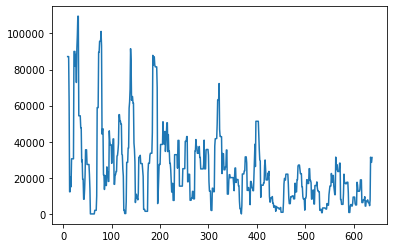

In [64]:
pd.DataFrame(epochs.get(0)).loss.rolling(10).mean().plot()

<AxesSubplot:>

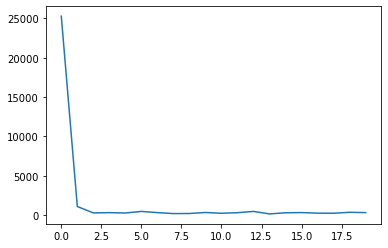

In [56]:
pd.DataFrame([pd.DataFrame(epochs.get(i)).mean() for i in epochs]).loss.plot()

In [ ]:
acc